# AI Student Performance Prediction

## Data Understanding

Made By: Soumik Dash

---

### Objectives

- Load the dataset
- Understand its structure
- Explore features
- Identify missing values
- Generate basic statistics

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better plot resolution
plt.rcParams["figure.figsize"] = (8,5)

# Display all columns
pd.set_option("display.max_columns", None)

# Display all rows if needed
pd.set_option("display.max_rows", 100)

In [2]:
#load the dataset

df = pd.read_csv("../data/raw/student_performance.csv")

print("Dataset loaded succesfully!")

Dataset loaded succesfully!


In [3]:
#show first 5 rows

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
#show last 5 rows

df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [5]:
# shape of the dataset

df.shape

(6607, 20)

## Feature Classification

### Numerical Features
- Hours_Studied
- Attendance
- Sleep_Hours
- Previous_Scores
- Tutoring_Sessions
- Physical_Activity

### Binary Categorical Features
- Internet_Access
- Extracurricular_Activities
- Learning_Disabilities

### Nominal Categorical Features (No Order)
- Gender
- School_Type

### Ordinal Categorical Features (Has Order)
- Parental_Involvement
- Access_to_Resources
- Motivation_Level
- Family_Income
- Teacher_Quality
- Peer_Influence
- Parental_Education_Level
- Distance_from_Home

### Target Variable
- Exam_Score

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [8]:
df.describe(include="object")

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


In [9]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## Observations

- Dataset contains **6607 student records**.
- There are **20 columns**, including **19 input features** and **1 target variable (`Exam_Score`)**.
- The dataset has **7 numerical** and **13 categorical** columns.
- Three columns contain missing values:
  - Teacher_Quality (78)
  - Parental_Education_Level (90)
  - Distance_from_Home (67)
- Missing values account for less than 2% of the dataset, making imputation a suitable strategy later.
- Numerical features appear to have realistic ranges, though `Exam_Score` has a maximum value of **101**, which deserves further investigation during EDA.

In [10]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

The goal of this section is to understand the distribution of variables and identify patterns before model training.

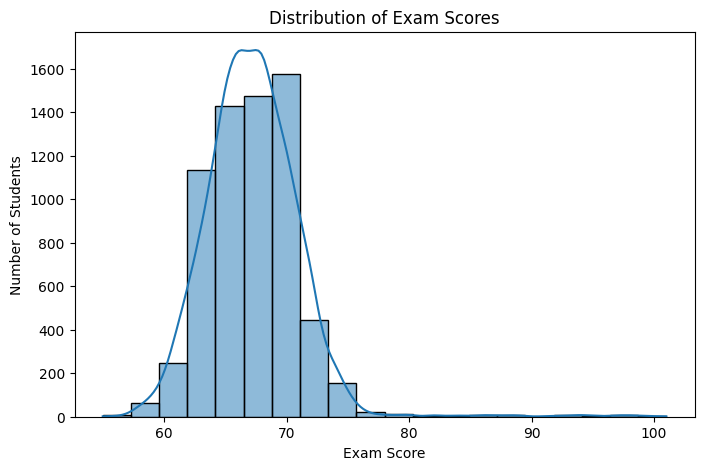

In [12]:
# Histogram of Exam Scores

plt.figure(figsize=(8,5))

sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

## Observation

- The distribution of `Exam_Score` is approximately bell-shaped.
- Most students scored between **65 and 70**.
- The distribution does not show significant left or right skewness.
- No obvious extreme outliers are visible.
- The maximum score of **101** appears to be a rare value but does not look suspicious from the histogram alone.

## Relationship Between Study Hours and Exam Score

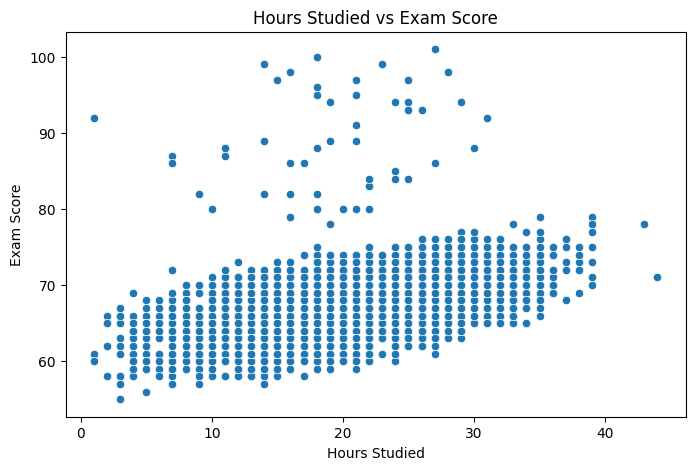

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score")
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

## Observation

- A moderate positive relationship exists between `Hours_Studied` and `Exam_Score`.
- Students who study more generally achieve higher scores.
- There are exceptions where students study less but still perform well.
- This suggests that study hours alone cannot explain exam performance, and multiple factors likely contribute.

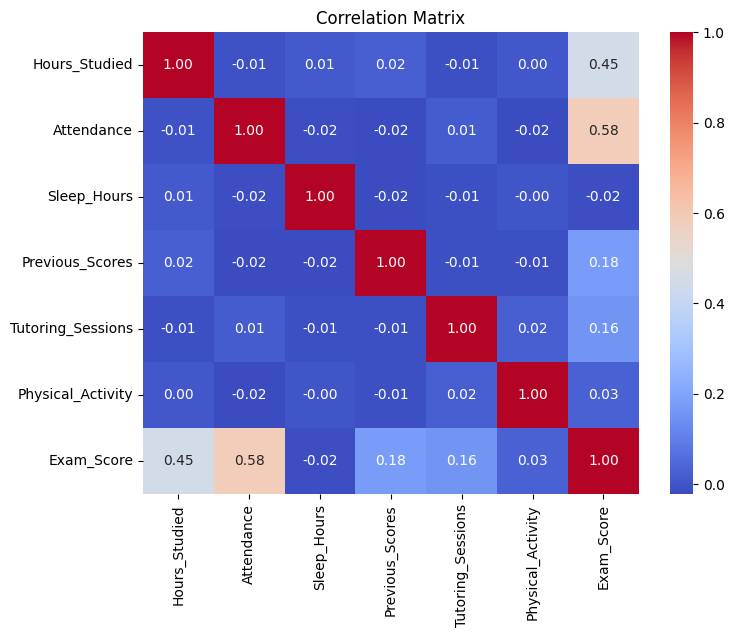

In [14]:
plt.figure(figsize=(8,6))

correlation = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Matrix Observations

- Attendance has the highest positive correlation (0.58) with `Exam_Score`.
- Hours_Studied also shows a moderate positive correlation (0.45).
- Sleep_Hours has almost no linear correlation (-0.02) with `Exam_Score`.
- The input features are not strongly correlated with each other, indicating low multicollinearity.
- No strong negative correlations are present among the numerical features.

## Family Income Distribution

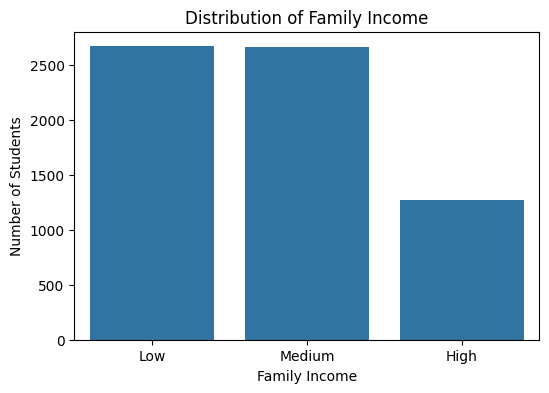

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Family_Income",
)

plt.title("Distribution of Family Income")
plt.xlabel("Family Income")
plt.ylabel("Number of Students")

plt.show()

## Family Income vs Exam Score

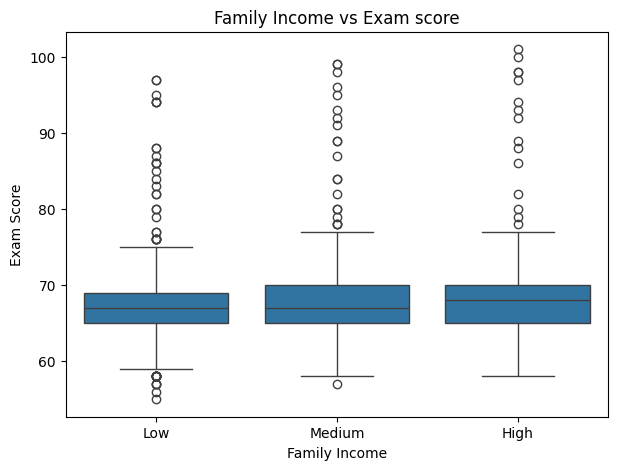

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Family_Income",
    y="Exam_Score"
)

plt.title("Family Income vs Exam score")
plt.xlabel("Family Income")
plt.ylabel("Exam Score")

plt.show()

## Observation

- Low and Medium income groups contain the largest number of students.
- The High income group has fewer students.
- Students from High income families have a slightly higher median exam score.
- The spread of exam scores is similar across all income groups.
- Outliers are present in every income category.
- Family income appears to have only a modest influence on exam scores.

## Teacher Quality vs Exam Score

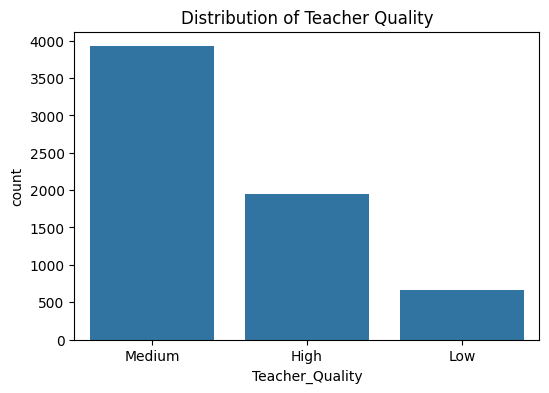

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Teacher_Quality"
)

plt.title("Distribution of Teacher Quality") 

plt.show()

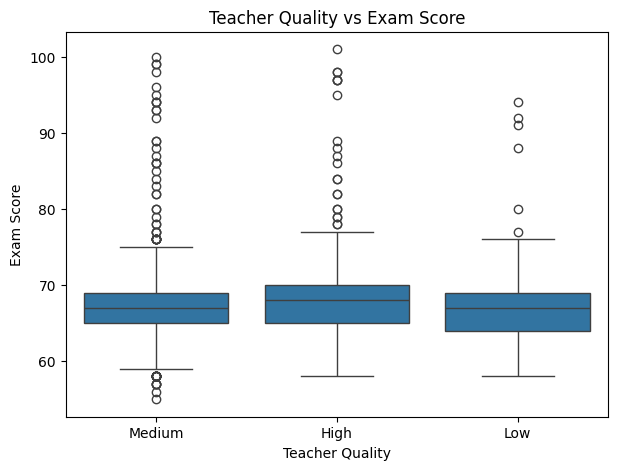

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Teacher_Quality",
    y="Exam_Score"
)

plt.title("Teacher Quality vs Exam Score")
plt.xlabel("Teacher Quality")
plt.ylabel("Exam Score")

plt.show()

## Observation

- Medium Teacher Quality is the most common category.
- Low Teacher Quality is the least common.
- Students with High Teacher Quality tend to have a slightly higher median exam score.
- The improvement exists but is moderate rather than dramatic.
- Teacher Quality appears to have a stronger relationship with Exam Score than Family Income.

## more efficient way for EDA using python function

In [19]:
def analyze_categorical_feature(feature):
    plt.figure(figsize=(12,4))

    #count plot
    plt.subplot(1,2,1)
    sns.countplot(
        data=df,
        x=feature
    )
    plt.title(f"Distribution of {feature}")

    #box plot
    plt.subplot(1,2,2)
    sns.boxplot(
        data=df,
        x=feature,
        y="Exam_Score"
    )
    plt.title(f"{feature} vs Exam Score")

    plt.tight_layout()
    plt.show()

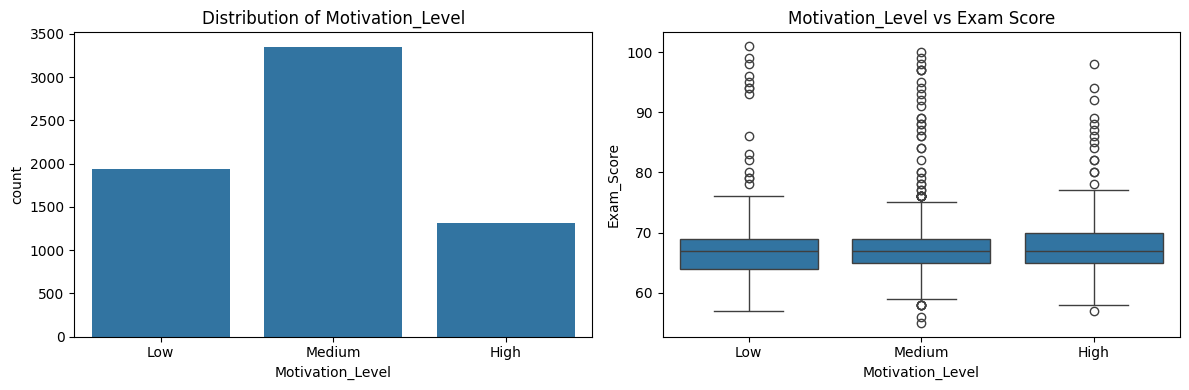

In [20]:
analyze_categorical_feature("Motivation_Level")

## Observation

- Medium motivation is the most common category.
- High motivation students have a slightly higher median exam score.
- The difference between motivation levels is small.
- Motivation appears to have a weaker relationship with exam score than Teacher Quality.
- Despite the small effect, Motivation Level may still provide useful information when combined with other features.

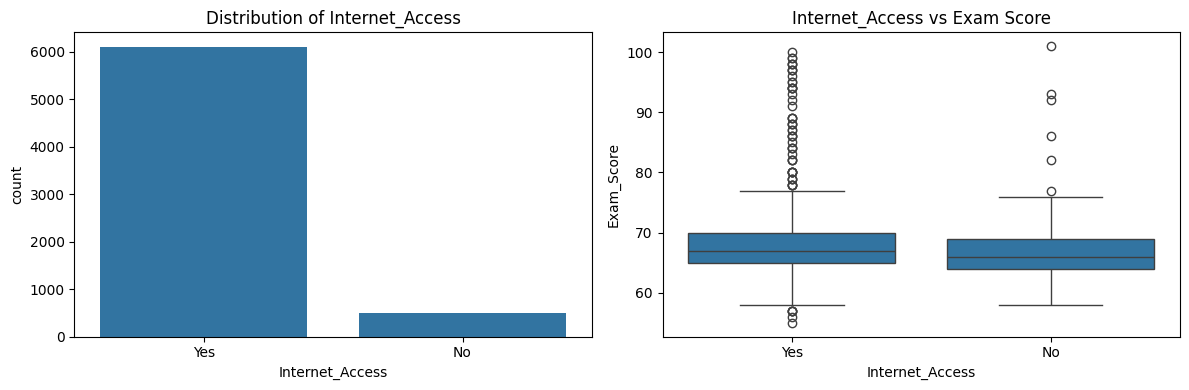

In [21]:
analyze_categorical_feature("Internet_Access")

## DATA PREPROCESSING

In [22]:
df[
    [
        "Teacher_Quality",
        "Parental_Education_Level",
        "Distance_from_Home"
    ]
].mode()

,Teacher_Quality,Parental_Education_Level,Distance_from_Home
0,Medium,High School,Near


## Filling Null using Imputer from Scikit-learn

In [23]:
from sklearn.impute import SimpleImputer

In [24]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

In [25]:
categorical_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

df[categorical_columns] = categorical_imputer.fit_transform(
    df[categorical_columns]
)

## Train-Test Split

In [26]:
# Features (Independent Variables)
X = df.drop("Exam_Score", axis=1)

# Target (Dependent Variable)
y = df["Exam_Score"]

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [29]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5285, 19)
X_test : (1322, 19)
y_train: (5285,)
y_test : (1322,)


# Data Preprocessing

In this section, we prepare the dataset for machine learning.

The preprocessing steps include:

- Identifying categorical feature types
- Encoding categorical variables
- Preparing numerical features
- Building a preprocessing pipeline using ColumnTransformer

## Step 1: Import Required Libraries

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

## Step 2: Define Feature Categories

Categorical features are divided into two groups:

- Ordinal Features (have a natural order)
- Nominal Features (no natural order)

Different encoding techniques will be applied to each group.

In [31]:
ordinal_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Distance_from_Home",
    "Parental_Education_Level"
]

nominal_features = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender"
]

## Step 3: Define the Order for Ordinal Features

Instead of allowing the encoder to determine the category order automatically, we explicitly define the correct order.

This prevents incorrect alphabetical encoding.

In [32]:
ordinal_categories = [
    ["Low", "Medium", "High"],                 # Parental_Involvement
    ["Low", "Medium", "High"],                 # Access_to_Resources
    ["Low", "Medium", "High"],                 # Motivation_Level
    ["Low", "Medium", "High"],                 # Family_Income
    ["Low", "Medium", "High"],                 # Teacher_Quality
    ["Negative", "Neutral", "Positive"],       # Peer_Influence
    ["Near", "Moderate", "Far"],               # Distance_from_Home
    ["High School", "College", "Postgraduate"] # Parental_Education_Level
]

## Step 4: Create the Encoders

- OrdinalEncoder is used for ordered categorical variables.
- OneHotEncoder is used for unordered categorical variables.

In [33]:
ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories
)

nominal_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

## Step 5: Create a ColumnTransformer

ColumnTransformer applies different preprocessing techniques to different groups of columns.

- Ordinal features → OrdinalEncoder
- Nominal features → OneHotEncoder
- Numerical features → Passed through unchanged

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal",
            ordinal_encoder,
            ordinal_features
        ),
        (
            "nominal",
            nominal_encoder,
            nominal_features
        )
    ],
    remainder="passthrough"
)

## Step 6: Fit the Preprocessor on Training Data

The preprocessing pipeline is fitted only on the training data to prevent data leakage.

The same learned transformations are then applied to the test data.

In [35]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

## Step 7: Verify the Processed Data

In [36]:
print(type(X_train_processed))
print(X_train_processed.shape)

print(type(X_test_processed))
print(X_test_processed.shape)

<class 'numpy.ndarray'>
(5285, 24)
<class 'numpy.ndarray'>
(1322, 24)


## Step 8: Observations

After preprocessing:

- Missing values have been handled.
- Ordinal categorical features have been encoded using `OrdinalEncoder`.
- Nominal categorical features have been encoded using `OneHotEncoder`.
- Numerical features have been passed through unchanged.
- The processed dataset is now represented as a NumPy array.
- The number of features increased from 19 to 24 because One-Hot Encoding expands categorical variables into multiple binary columns.

# Model Training

In this section, we will train our first Machine Learning model.

We start with **Linear Regression**, which is one of the simplest and most interpretable regression algorithms.

The workflow includes:

- Building a preprocessing pipeline
- Training the model
- Making predictions
- Evaluating model performance

## Step 1: Import Required Libraries

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

## Step 2: Build the Machine Learning Pipeline

For Linear Regression, numerical features are standardized using `StandardScaler`.

The pipeline performs:

1. Feature Scaling
2. Model Training

In [38]:
linear_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]
)

## Step 3: Train the Model

The model learns the relationship between the input features and the target variable using the training dataset.

In [39]:
linear_pipeline.fit(X_train_processed, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

## Step 4: Make Predictions

In [40]:
y_pred = linear_pipeline.predict(X_test_processed)

## Step 5: Inspect the Predictions

Compare a few predicted values with the actual exam scores.

In [41]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,65,64.633926
1,65,65.306778
2,71,71.533340
3,64,64.316543
4,66,66.426895
5,66,66.586075
6,72,72.517715
7,66,66.373184
8,70,70.029434
9,70,70.045059


## Step 6: Evaluate the Model

Predictions alone do not tell us whether a model is good.

Regression models are evaluated using several metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Each metric provides different insights into model performance.

## Step 7: Import Evaluation Metrics

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

## Step 8: Calculate the Evaluation Metrics

In [43]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

## Step 9: Display the Results

In [44]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.45
MSE  : 3.24
RMSE : 1.80
R²   : 0.7708


## Step 10: Interpretation of Results

The Linear Regression model achieved the following performance:

- MAE: 0.45
- RMSE: 1.80
- R² Score: 0.7708

### Observations

- The model predicts exam scores with a low average error.
- The RMSE indicates that larger prediction errors are relatively infrequent.
- The R² score shows that approximately 77% of the variation in exam scores is explained by the model.
- These results provide a strong baseline for comparison with more complex machine learning models.

# Model Analysis

Before trying more complex algorithms, we analyze the performance of our Linear Regression model.

This helps us understand:

- Prediction quality
- Error distribution
- Model assumptions

## Actual vs Predicted Values

A good regression model should produce predictions that lie close to the ideal diagonal line.

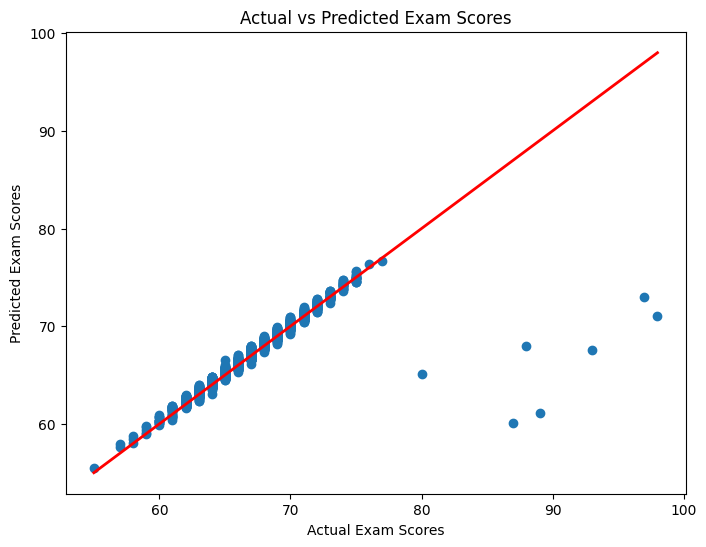

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = "red",
    linewidth=2
)

plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

## Residual Analysis

Residuals represent the prediction errors made by the model.

A good regression model should have residuals randomly distributed around zero.

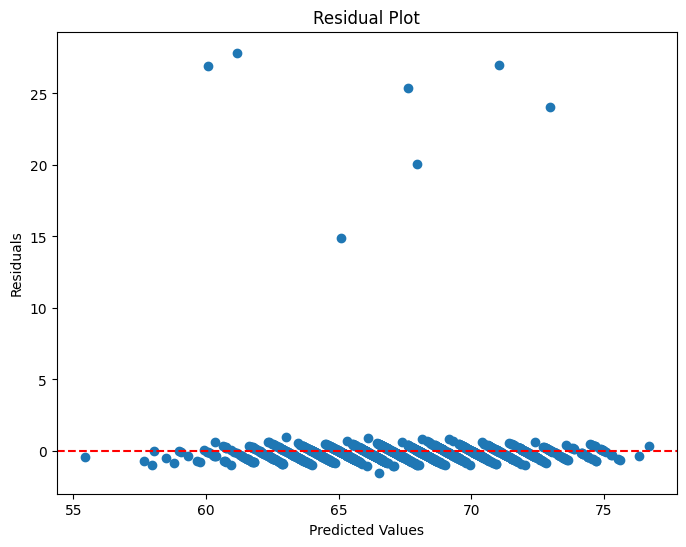

In [47]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Residual Distribution

Ideally, the residuals should approximately follow a normal distribution centered around zero.

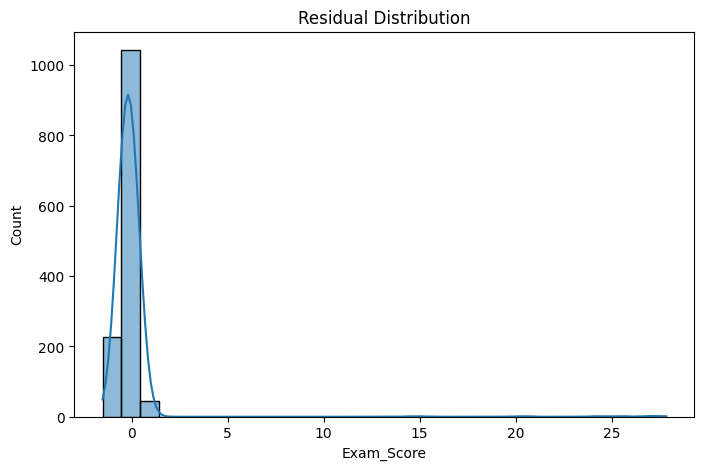

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

## Model Analysis

### Actual vs Predicted Plot

- Most predictions closely follow the ideal diagonal line.
- The model performs well for the majority of students.
- High exam scores tend to be underestimated.

### Residual Plot

- Most residuals are centered around zero.
- A few large positive residuals indicate significant underestimation for some students.
- No strong systematic pattern is observed for the majority of predictions.

### Residual Distribution

- Residuals are concentrated around zero.
- The distribution shows a right-skew due to a small number of large prediction errors.
- Overall, the model provides a good baseline but may not capture complex relationships in the data.

# Decision Tree Regression

Decision Tree is a non-linear supervised learning algorithm.

Unlike Linear Regression, Decision Trees recursively split the data into smaller regions based on feature values.

They are capable of learning complex relationships without requiring feature scaling.

## Step 1: Import Required Libraries

In [49]:
from sklearn.tree import DecisionTreeRegressor

## Step 2: Create the Decision Tree Model

We initialize a Decision Tree Regressor.

The parameter `random_state` ensures reproducibility of the results.

In [50]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

## Step 3: Train the Model

In [51]:
decision_tree.fit(
    X_train_processed,
    y_train
)

DecisionTreeRegressor(random_state=42)

## Step 4: Make Predictions

In [52]:
dt_predictions = decision_tree.predict(
    X_test_processed
)

## Step 5: Evaluate the Model

In [53]:
dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

dt_mse = mean_squared_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

In [54]:
print(f"MAE  : {dt_mae:.2f}")
print(f"MSE  : {dt_mse:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

MAE  : 1.60
MSE  : 9.14
RMSE : 3.02
R²   : 0.3537


## Decision Tree Results

The default Decision Tree performed significantly worse than the Linear Regression model.

### Observations

- The model achieved a lower R² score.
- Prediction errors increased substantially.
- The unrestricted tree likely overfit the training data.
- This demonstrates the importance of controlling model complexity.

In [55]:
decision_tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [56]:
decision_tree.fit(X_train_processed, y_train)

dt_predictions = decision_tree.predict(X_test_processed)

In [57]:
dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

dt_mse = mean_squared_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

In [58]:
print(f"MAE  : {dt_mae:.2f}")
print(f"MSE  : {dt_mse:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

MAE  : 1.59
MSE  : 6.42
RMSE : 2.53
R²   : 0.5461


## Tuned Decision Tree Results

Hyperparameter tuning improved the Decision Tree's performance by reducing overfitting.

### Comparison with Default Decision Tree

- RMSE decreased from 3.02 to 2.53.
- R² increased from 0.35 to 0.55.

### Comparison with Linear Regression

Despite the improvements, the Decision Tree still performed worse than Linear Regression.

This suggests that the dataset exhibits predominantly linear relationships, making Linear Regression a more suitable model.